In [44]:
import numpy as np
import os
from micado_misthic import misthic_func
from configobj import ConfigObj
from micado_misthic.utils.obsparams import * 
import matplotlib as mpl

### Main directory of the repos
repository_dir              = 'C:/Users/Red Slottje/Documents/micado_misthic'

### directory with flux & transmission data for MICADO
flux_dir                    = repository_dir + '/flux_data/'

### directories with the coronagraphic simulated images
all_coro_sim_dir_prefix     = 'D:/FROM_RED/coro_sims/'

### directories to record the processed data
record_dir_prefix     = 'D:/FROM_RED/coro_adi_new/ADI/'


###-- Observation params
coronagraph     = 'CLC1' # 'CLC0' or 'CLC1'
quartile        = 'MED'#['Q1', 'Q4', 'MED']
keyword_NCPA    = 'NoNCPA' 
lbd             = 1.190 # Choose filter
p_dist_mas      =100.000
duree = [30.0]
pixscale_in_mas = 1.5 # 1.5 or 4 mas


coro_sim_dir         = all_coro_sim_dir_prefix + f'{coronagraph}_{quartile}_NoNCPA/lambda={lbd:5.3f}/TURBU_ABERR/duree={duree[0]}min/'
#coro_resized_dir    =  record_dir_prefix + f'D:\FROM_RED\resized_fft_coro\CLC1_Q1_noNCPA\lbd={lbd}_pxscale={pixscale_in_mas}'
coro_resized_dir = record_dir_prefix
planet_resized_dir = record_dir_prefix+'PLANET/'

### path to the configspec file (same as the misthic_func.py module)
configspec_file   = os.path.dirname(misthic_func.__file__)+'/misthic_configspec.ini'

### Read infos from the .ini file of the directory to process
ini_file = [f for f in os.listdir(coro_sim_dir) if f.endswith('.ini')][0]
config  = ConfigObj(coro_sim_dir+ini_file, configspec=configspec_file)
detector_sampling = np.float32(config['detectorconfig']['detector_sampling']) ## Sampling for initial simulation
frame_exp_time  = np.float32(config['simuconfig']['delta_t']) ## exposure time per frame in seconds 



Resizing of the images to simulate the right detector sampling of MICADO

-- Coro Img: Resizing
(180, 384, 384) 3.0 1.19 1.5


C:\Users\Red Slottje\Documents\micado_misthic\micado_misthic\imgproc\imgproc.py:343: ComplexWarning: Casting complex values to real discards the imaginary part
  resized_fft[i] = shift4


Cube Type after resizing: <class 'numpy.float64'>
<class 'numpy.ndarray'> (544, 544)
1.19


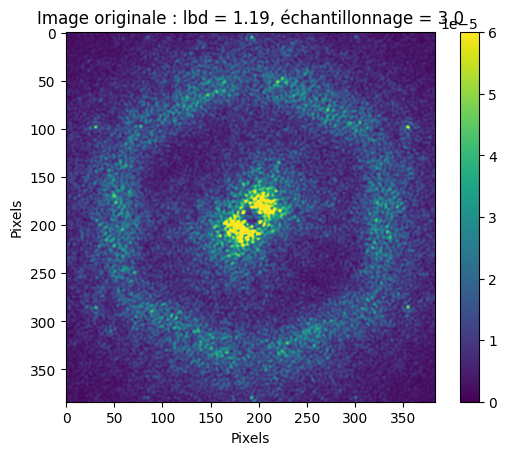

In [45]:
from micado_misthic.imgproc import fft_resize
from astropy.io import fits

if not os.path.exists(coro_resized_dir):
            os.makedirs(coro_resized_dir)  

print('-- Coro Img: Resizing')
coro_file = [f for f in os.listdir(coro_sim_dir) if f.endswith('_image_cube.fits')][0]
HDU_coro = fits.open(coro_sim_dir+coro_file)
cube_coro = HDU_coro[0].data

print(np.shape(cube_coro),detector_sampling, lbd, pixscale_in_mas)
          
cube_coro_resized, coro_scale_coeff = fft_resize(cube_coro, lbd, detector_sampling, pixscale_in_mas) #, write_dir=coro_resized_dir+f'image_cube_{lbd:5.3f}_{duree[0]}min_',  plotting=False)
print(type(cube_coro_resized), cube_coro_resized[1].shape)

fig, ax = plt.subplots()
plt.title(f'Image originale : lbd = {lbd}, échantillonnage = {detector_sampling}')#, pixscale = {pixscale_in_mas}')
plt.imshow(cube_coro[1], cmap = 'viridis', vmin = 0, vmax = 6*10**-5)
plt.colorbar(cmap = 'viridis', ax= ax)
plt.ylabel('Pixels')
plt.xlabel('Pixels')
#plt.savefig(f'D:/FROM_RED/flux_and_contrasts/Rapport/image_originale_lbd={lbd}.png')
print(lbd)

Same for psf image to allow normalization (calculate the contrast)

-- Coro Img: Resizing psf for normalization
Cube Type after resizing: <class 'numpy.float64'>
20260721_112635_occulter_perfect_psf.fits


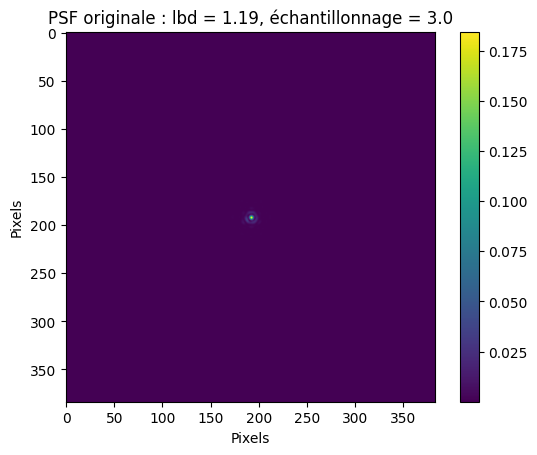

1.19


In [46]:
print('-- Coro Img: Resizing psf for normalization')

psf_file = [f for f in os.listdir(coro_sim_dir) if f.endswith('_psf_cube.fits')][0]
HDU_psf = fits.open(coro_sim_dir+psf_file)
cube_psf = HDU_psf[0].data
cube_psf_resized, coro_scale_coeff     = fft_resize(cube_psf, lbd, detector_sampling, pixscale_in_mas)#, write_dir=coro_resized_dir+f'psf_cube_{lbd:5.3f}_{duree[0]}min_',  plotting=False)


perf_psf_file = [f for f in os.listdir(coro_sim_dir) if f.endswith('perfect_psf.fits')][0]
print(perf_psf_file)
HDU_perf_psf = fits.open(coro_sim_dir+perf_psf_file)
perf_psf = HDU_perf_psf[0].data
#cube_psf_resized, coro_scale_coeff     = fft_resize(cube_psf, lbd, detector_sampling, pixscale_in_mas)#, write_dir=coro_resized_dir+f'psf_cube_{lbd:5.3f}_{duree[0]}min_',  plotting=False)

fig, ax = plt.subplots()
plt.title(f'PSF originale : lbd = {lbd}, échantillonnage = {detector_sampling}')
plt.imshow(cube_psf[0], cmap = 'viridis')
plt.colorbar(cmap = 'viridis', ax= ax)
plt.ylabel('Pixels')
plt.xlabel('Pixels')
#plt.savefig(f'D:/FROM_RED/flux_and_contrasts/Rapport/psf_originale_lbd={lbd}.png')

plt.show()
print(lbd)

Apply ADI on the coronagraph image (without noise for now)

In [47]:
from micado_misthic.imgproc import micado_adi

print("Beginning coro ADI processing")
adi_sum_coro_resized, psf_sum_coro_resized = micado_adi(cube_coro_resized, cube_psf_resized, coro_sim_dir)
print(cube_coro_resized.shape)


Beginning coro ADI processing
Standard dev of image cube after noise and ADI: 5.532347705183572e-05
(180, 544, 544)


544


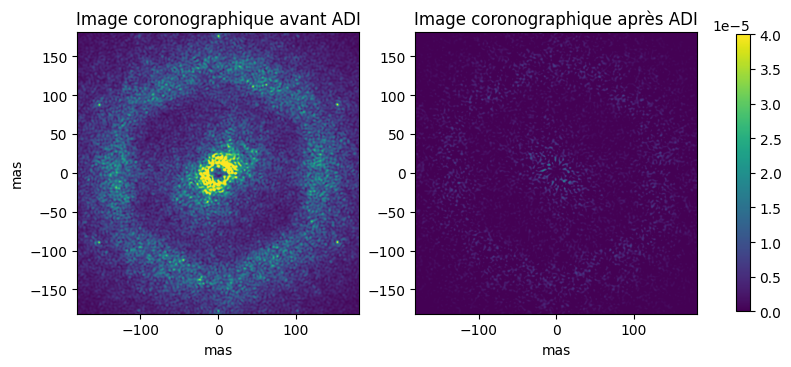

1.19


In [48]:
# Show the ADI post-process image

import matplotlib.pyplot as plt

# changing the axis units from pixels to mas
scale_in_mas = adi_sum_coro_resized.shape[1]/pixscale_in_mas
scale_in_pix = adi_sum_coro_resized.shape[1]
print(scale_in_pix)


fig, ax = plt.subplots(1,2, figsize = (10, 6))
ax[0].imshow(cube_coro_resized[0], extent=[-scale_in_mas/2,scale_in_mas/2,-scale_in_mas/2,scale_in_mas/2], vmin = 0, vmax= 6*10**-5)
img = ax[1].imshow((adi_sum_coro_resized/np.max(psf_sum_coro_resized)), origin='lower', extent=[-scale_in_mas/2,scale_in_mas/2,-scale_in_mas/2,scale_in_mas/2], cmap = 'viridis', vmin = 0, vmax = 4*10**-5)#, aspect=4)
fig.colorbar(img, ax = ax, shrink = 0.6)
#plt.imshow(adi_sum_coro_resized/np.max(psf_sum_coro_resized))
ax[0].set_title(f'Image coronographique avant ADI')# lbd = {lbd}µm')
ax[0].set_xlabel(f'mas')
ax[1].set_xlabel(f'mas')
ax[0].set_ylabel(f'mas')
ax[1].set_title(f'Image coronographique après ADI')# lbd = {lbd}µm')

#plt.savefig(f'D:/FROM_RED/flux_and_contrasts/Rapport/ADI_NOPLANET_lbd={lbd}.png')
#plt.xlabel('mas')
plt.show()
print(lbd)


In [49]:
# Show the RMS radial contrast

from micado_misthic.analysis import get_rms_contrast

rms_contrast_resized, x = get_rms_contrast(adi_sum_coro_resized/np.max(psf_sum_coro_resized))


#contrast_curve, xx = get_rms_contrast(fits.getdata('D:/FROM_RED/20260914_154432/No_Planet_CLC25_NoNCPA_MED_H1.635_m_samp1.5_noise_adi_sum.fits'))


In [50]:
def get_contrast_from_contrast_curve_file(fits_path, distance_in_mas):
    """
    By Trisan Deseine (June 2026)
    Get the contrast value from a contrast curve FITS file at a given distance in milliarcseconds (mas).
    
    Parameters:
    - fits_path: str or Path, path to the FITS file containing the contrast curve.
    - distance_in_mas: float, the distance in milliarcseconds for which to retrieve the contrast.
    
    Returns:
    - contrast_value: float, the contrast value at the specified distance. Returns None if the distance is out of bounds.
    """
    
    # Open the FITS file and read the data
    with fits.open(fits_path) as hdul:
        data = hdul[1].data  # Assuming the contrast curve is in the first extension
    
    # Extract separation and contrast values
    separations = data['separation_mas']
    contrasts = data['contrast_5sigma']
    
    # Find the index of the closest separation value
    idx = (np.abs(separations - distance_in_mas)).argmin()
    
    # Check if the closest separation is within a reasonable range 
    if np.abs(separations[idx] - distance_in_mas) <= 1.0:
        return contrasts[idx]
    else:
        return None  # Return None if the distance is out of bounds
    

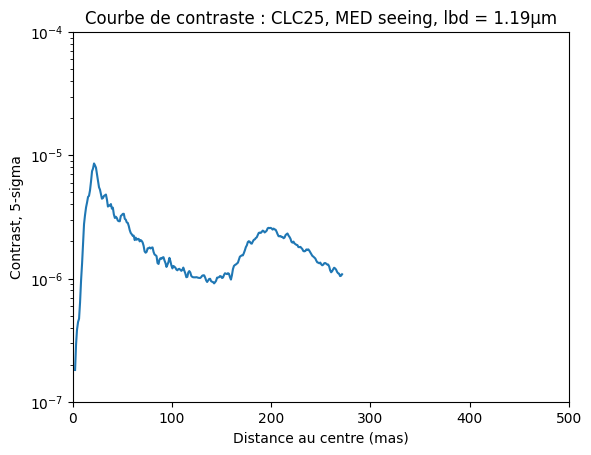

In [52]:
#Plot the 5 sigma contrast versus angular_distance in mas 
from astropy.table import Table
pixscale_in_mas= 1.5
sep = [100, 100]
ang_sep = [14.94788779, 24.93227423, 50.29683633, 100.31542703, 200.30947955, 400.31212168]
mic_sens = [10**-6, 10**-5]
exemple=[]

# contrast_curve_adi = fits.getdata('D:/FROM_RED/20260914_154432/No_Planet_CLC25_NoNCPA_MED_H1.635_m_samp1.5_noise_contrast_curve.fits')
# t = Table(contrast_curve_adi, names = ('x', 'rms_contrast'))
# xy = t['x']
# rms_contrast = t['rms_contrast']

# #print(xy)
# #mic_sens.append([get_contrast_from_contrast_curve_file(f'D:/FROM_RED/resampled_by_tristan/No_Planet/{coronagraph}/NoNCPA/{quartile}/filter{lbd}/Samp1.5/No_Planet_CLC25_NoNCPA_{quartile}_H{lbd}_m_samp1.5_no_noise_contrast_curve.fits',sep[i]) for i in range(len(sep))])
# #mic_sens.append([get_contrast_from_contrast_curve_file()])
# for i in range(len(ang_sep)):
#     for j in range(len(x)):
#         if round(x[j]/pixscale_in_mas, 3)== round(ang_sep[i], 3):
#             exemple.append(rms_contrast_resized[j]*5.)
# plt.scatter(ang_sep, exemple, c = ('tab:brown', 'tab:blue', 'tab:orange', 'tab:green'))#, 'tab:red', 'tab:purple'), zorder = 2 )
# plt.plot(x/pixscale_in_mas,rms_contrast_resized*5., zorder = 1)
# plt.vlines(50, 10**-7, 10**-4, colors = 'k')
# #plt.scatter(sep, mic_sens, marker ='o', color = 'r')

plt.title(f'Courbe de contraste : CLC25, {quartile} seeing, lbd = {lbd}µm')#, pixscale  = {pixscale_in_mas}mas, lambda = {lbd}µm')
plt.plot(x, rms_contrast_resized)
plt.xlabel("Distance au centre (mas)")
plt.xlim(0, 500)
plt.ylim(10**-7, 10**-4)
plt.ylabel("Contrast, 5-sigma")
plt.yscale('log')
plt.show()

ang_sep = [26.043888920575593, 50.13767767247084, 99.65761789905076, 200.21862073655, 399.7086394864949]

#plt.plot(xx, contrast_curve)
# #plt.ylim(10**-7, 10**-4)
# plt.ylabel("Contrast, 5-sigma")
# plt.show()
# for i in range(len(ang_sep)):
#     for j in range(len(t['x'])):
#         print((t['x'][j]))
#         if round(t['x'][j], 3)== round(ang_sep[i], 3):
#             print(round(t['x'][j]))
#             exemple.append(t['rms_contrast'][j])
# plt.scatter(ang_sep, exemple, c = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple'), zorder = 2 )
# plt.plot(t['x'], t['rms_contrast'], zorder = 1)
# plt.vlines(25, 10**-7, 10**-4, colors = 'k')

# plt.title(f'Courbe de contraste : CLC25, {quartile} seeing, lbd = {lbd}µm')#, pixscale  = {pixscale_in_mas}mas, lambda = {lbd}µm')
# plt.xlabel("Distance au centre (mas)")
# plt.ylabel("Contrast, 5-sigma")
# plt.ylim(10**-6, 10**-4)
# plt.yscale('log')

# # plt.plot(contrast_curve_adi.T)
# plt.show()
#plt.savefig(f'D:/FROM_RED/flux_and_contrasts/Rapport/{coronagraph}_contrast_curve_lbd={lbd}.png')

Now, what happens to the planet when ADI is applied?

In [53]:
#first, let's retrieve the simulation of a planet at a given separation

#planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, met, CO, dist_pc, r_pl, flux_dir=flux_dir)

dir_planet_prefix = 'D:/FROM_RED/planet_sims/' # Directory where different planets are located

#planet_separation = p_dist_mas:5.3f # in mas

dir_planet = dir_planet_prefix + f'{coronagraph}_{quartile}_NoNCPA/lambda={lbd:5.3f}/p_dist_mas={p_dist_mas:5.3f}/TURBU_ABERR/duree={duree[0]}min/'

#verification that parallactic angle is the same for planet and star (the paralactic angle value is read in adi processing)
table_planet = [f for f in os.listdir(dir_planet) if f.endswith('_parangle_tab.txt')][0]
parallactic_planet = np.loadtxt(dir_planet+table_planet,skiprows=1)
table_star = [f for f in os.listdir(coro_sim_dir) if f.endswith('_parangle_tab.txt')][0]
parallactic_star = np.loadtxt(coro_sim_dir+table_star,skiprows=1)
if np.sum(np.abs(parallactic_star-parallactic_planet)) >= 1e-5:
    print('Problem with parallactic angles btw star and planet')


In [ ]:
print('-- Load and resize planet cube')
planet_file = [f for f in os.listdir(dir_planet) if f.endswith('_image_cube.fits')][0]
HDU_planet = fits.open(dir_planet+planet_file)
cube_planet = HDU_planet[0].data
          
cube_planet_resized, planet_scale_coeff = fft_resize(cube_planet, lbd, detector_sampling, pixscale_in_mas)#, write_dir=planet_resized_dir+f'planet_cube_{lbd:5.3f}_{duree[0]}min',  plotting=False)

-- Load and resize planet cube
Cube Type after resizing: <class 'numpy.float64'>


In [ ]:
# print('--- Add photon noise to the cubes')

# planet_cube    = fits.getdata(dir_planet+planet_file)

# planet_cube_noisy, perf_psf_noisy, flux_per_frame = scale_to_photons(planet_cube, perf_psf_pl, 
#                                                                                     planet_photon_flux, planet_emission_per_pix, 
#                                                                                     frame_exp_time=frame_exp_time, sig_ron = ron, 
#                                                                                     no_noise=False)
# plpsf_cube_noisy, perf_psf_noisy, flux_per_frame = scale_to_photons(cube_psf_pl, perf_psf_pl, 
#                                                                                     planet_photon_flux, planet_emission_per_pix, 
#                                                                                     frame_exp_time=frame_exp_time, sig_ron = ron, 
#                                                                                     no_noise=False)

# print('planet_cube_noisy.shape=', planet_cube_noisy.shape)
# print('perf_psf_noisy.shape=', perf_psf_noisy.shape)
# print('planet_cube.shape=', planet_cube.shape)
# print('perf_psf_pl.shape =', perf_psf_pl.shape)

# # ADI
# print('----------')
# print("Beginning planet ADI processing")
# adi_sum_pl, psf_sum_pl = micado_adi(planet_cube_noisy, plpsf_cube_noisy, pl_sim_dir)

# # Convolution
# print('----------')
# print("Beginning planet image convolution")
    
# l_over_d_pix = lbd[i]*1e-6/tel_diam * 180./np.pi * 3600*1e3 / (pixscale_in_mas)
# mask_radius = l_over_d_pix * .5
# mask = get_circle_mask(adi_sum_pl.shape, mask_radius)

# print('mask planet.shape=', mask.shape)
# y_dim, x_dim = adi_sum_pl.shape

# conv_adi_pl = fftconvolve(adi_sum_pl, mask, mode='full')
# conv_psf_pl = fftconvolve(psf_sum_pl, mask, mode='full')


# y_dim2, x_dim2 = conv_adi_pl.shape
# y1 = int((y_dim2-y_dim+1)/2)
# y2 = y1 + y_dim

# conv_adi_pl = conv_adi_pl[y1:y2,y1:y2]
# conv_psf_pl = conv_psf_pl[y1:y2,y1:y2]       

# ### SAVE
# if not os.path.exists(pladi_img_dir):
#     os.makedirs(pladi_img_dir)
# fits.writeto(pl_adi_file, adi_sum_pl)
# fits.writeto(plpsf_adi_file, psf_sum_pl)
# fits.writeto(pl_adi_conv_file, conv_adi_pl)
# fits.writeto(plpsf_adi_conv_file, conv_psf_pl)

# norm_adi_pl = conv_adi_pl / max_psf_coro 

In [ ]:
print("Apply ADI processing on planet")
adi_sum_planet_resized, psf_sum_planet_resized = micado_adi(cube_planet_resized, cube_psf_resized, coro_sim_dir)


Apply ADI processing on planet
Standard dev of image cube after noise and ADI: 0.23086374547621205


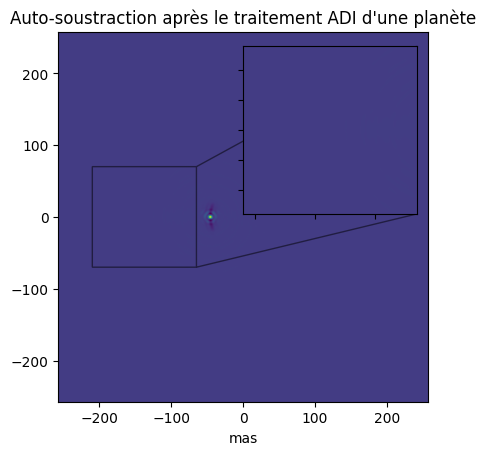

In [ ]:
# Show the ADI post-process image
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.imshow(adi_sum_planet_resized/np.max(psf_sum_planet_resized), origin='lower', extent=[-scale_in_mas/2,scale_in_mas/2,-scale_in_mas/2,scale_in_mas/2])

#x1,x2, y1, y2 = -0.00013, -0.00003, -0.00005, 0.00005
x1, x2, y1, y2 = -210 , -65, -70, 70
axins = ax.inset_axes([0.5, 0.5, 0.47, 0.47], xlim=(x1, x2), ylim=(y1, y2),xticklabels=[], yticklabels=[])
axins.imshow(adi_sum_planet_resized/np.max(psf_sum_planet_resized), origin="lower", extent=[-scale_in_mas/2,scale_in_mas/2,-scale_in_mas/2,scale_in_mas/2])
ax.indicate_inset_zoom(axins,  edgecolor="black")
plt.title('Auto-soustraction après le traitement ADI d\'une planète')
#plt.savefig(f'D:/FROM_RED/flux_and_contrasts/Rapport/ADI_PLANETONLY_lbd={lbd}.png')
plt.xlabel('mas')
plt.savefig('')
plt.show()



0.0
0.7737588160760597


Text(0, 0.5, "Millisecondes d'arc")

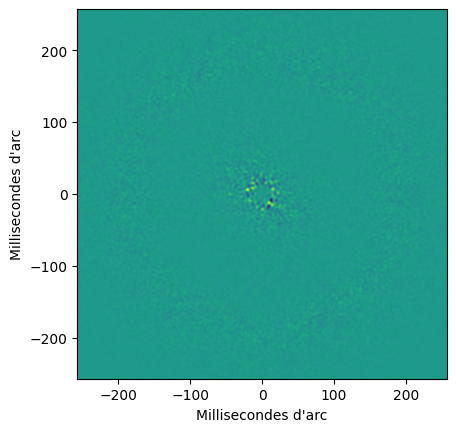

In [ ]:
# Image of star + planet at a given distance
# 
#remarque: psf_sum_planet_resized et psf_sum_coro_resized sont identiques. Ce sont des tableaux utiliser pour la normalisation
print(np.max(np.abs(psf_sum_planet_resized-psf_sum_coro_resized))) # =0 s'ils sont identiques
print(np.max(adi_sum_planet_resized/np.max(psf_sum_planet_resized))) # Attenuation of hte planet flux due to ADI processing. It will increase for smaller separation and less variation of parallactic angle


plt.imshow((adi_sum_coro_resized+ 1e-5*adi_sum_planet_resized)/np.max(psf_sum_coro_resized), origin='lower', extent=[-scale_in_mas/2,scale_in_mas/2,-scale_in_mas/2,scale_in_mas/2])

plt.xlabel('Millisecondes d\'arc')
plt.ylabel('Millisecondes d\'arc')
#plt.savefig(f'D:/FROM_RED/flux_and_contrasts/Rapport/full_adi_lbd={lbd}_pxscl={pixscale_in_mas}_dist={p_dist_mas}.png')



mask coro.shape= (772, 772)
mask planet.shape= (772, 772)
adi_sum_pl.shape = (772, 772)
conv_adi_pl.shape = (1543, 1543)


Text(0, 0.5, '[arcsec]')

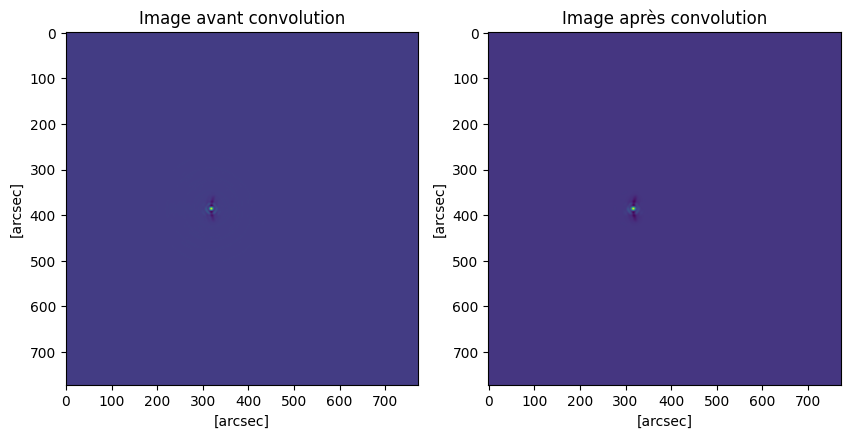

In [ ]:
from micado_misthic.imgproc import get_circle_mask
from scipy.signal import fftconvolve

tel_diam        = 38.542


l_over_d_pix = lbd*1e-6/tel_diam * 180./np.pi * 3600*1e3 / (pixscale_in_mas)
mask_radius = l_over_d_pix * .5
mask = get_circle_mask(adi_sum_coro_resized.shape, mask_radius)

print('mask coro.shape=', mask.shape)

# conv_adi_coro = convolution(adi_sum_coro, mask)
# conv_psf_coro = convolution(psf_sum_coro, mask)

y_dim, x_dim = adi_sum_coro_resized.shape
conv_adi_coro = fftconvolve(adi_sum_coro_resized, mask, mode='full')
conv_psf_coro = fftconvolve(psf_sum_coro_resized, mask, mode='full')

y_dim2, x_dim2 = conv_adi_coro.shape
y1 = int((y_dim2-y_dim+1)/2)
y2 = y1 + y_dim
conv_adi_coro = conv_adi_coro[y1:y2,y1:y2]
conv_psf_coro = conv_psf_coro[y1:y2,y1:y2]

mask = get_circle_mask(adi_sum_planet_resized.shape, mask_radius)
                
print('mask planet.shape=', mask.shape)
print('adi_sum_pl.shape =', adi_sum_planet_resized.shape)
y_dim, x_dim = adi_sum_planet_resized.shape

conv_adi_pl = fftconvolve(adi_sum_planet_resized, mask, mode='full')
conv_psf_pl = fftconvolve(psf_sum_planet_resized, mask, mode='full')
print('conv_adi_pl.shape =', conv_adi_pl.shape)

y_dim2, x_dim2 = conv_adi_pl.shape
y1 = int((y_dim2-y_dim+1)/2)
y2 = y1 + y_dim

conv_adi_pl = conv_adi_pl[y1:y2,y1:y2]
conv_psf_pl = conv_psf_pl[y1:y2,y1:y2]   



figu, axes = plt.subplots(1,2, figsize = (10,6))
axes[0].imshow(adi_sum_coro_resized+adi_sum_planet_resized)
axes[0].set_title('Image avant convolution')
axes[0].set_xlabel('[arcsec]')
axes[0].set_ylabel('[arcsec]')
axes[1].imshow(conv_adi_coro+ conv_adi_pl)
axes[1].set_title('Image après convolution')
axes[1].set_xlabel('[arcsec]')
axes[1].set_ylabel('[arcsec]')

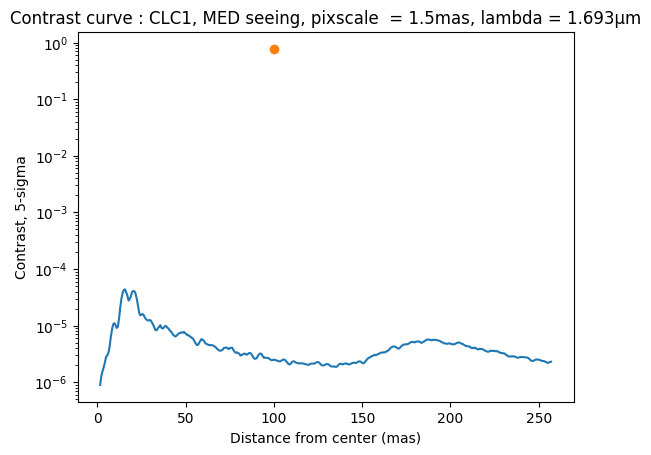

In [ ]:
rms_contrast, x = get_rms_contrast((adi_sum_coro_resized+ 1e-5*adi_sum_planet_resized)/np.max(psf_sum_coro_resized))

max_planet = np.max(adi_sum_planet_resized) / np.max(psf_sum_coro_resized)

plt.plot(x/pixscale_in_mas,rms_contrast_resized*5.)
#plt.suptitle(f"Contrast curve: {coronagraph} {quartile} ADI image at lambda={lbd[i]:5.3f}, pxscale={pixscale_in_mas}, Mag unknown",fontsize=12)
#plt.title('Planet: {} R_Jup, {} pc, {}K, logg={}, met={:.2f}, CO ratio={:3.2f}'.format(r_pl, dist_pc, temp, logg, met, CO),fontsize=10)
plt.plot(p_dist_mas, max_planet, 'o')
plt.title(f'Contrast curve : {coronagraph}, MED seeing, pixscale  = {pixscale_in_mas}mas, lambda = {lbd}µm')
plt.xlabel("Distance from center (mas)")
plt.ylabel("Contrast, 5-sigma")
plt.yscale('log')
plt.show()


In [ ]:
################# SETUP FOR THE CONTRAST PLOTS (Define star temperature here) #####################

# extracting the filter data from the input files
tr_filter0  = fits.getdata(flux_dir+'Transmission_filter_J1J2H1H2K1K2_v2020.fits')
tr_filter1  = fits.getdata(flux_dir+'Transmission_filter_JHK.fits')
wave_tr     = fits.getdata(flux_dir+'Wavelength_for_emission_transmission_in_micrometer.fits')
    
wave_step   = np.mean(np.diff(wave_tr))

#defining the bands from the filter 
Jshort = tr_filter0[0,:] #lbd = 1.190
Jlong = tr_filter0[1,:] #lbd = 1.270
Hshort = tr_filter0[2,:] #lbd = 1.582
Hlong = tr_filter0[3,:] #lbd = 1.693
Kmid = tr_filter0[4,:] # lbd = 2.100
K2 = tr_filter0[5,:]  #lbd = 2.220
Jbroad = tr_filter1[0,:] #lbd = 1.245
Hbroad = tr_filter1[1,:] #lbd = 1.635
Kbroad = tr_filter1[2,:] #lbd = 2.145

tr_filter = [Jshort, Jlong, Hshort, Hlong, Kmid, K2]
tr_filter_broad = [Jbroad, Hbroad, Kbroad]

tr_filter_J = [Jshort, Jlong]
tr_filter_H = [Hshort, Hlong]
tr_filter_K = [Kmid, K2]

lbd = [0.299, 0.550, 1.2475, 1.635, 2.150, 2.500]

# pick the star temperature here
temp_star = 7400

# star_mag = []
# for j in range(len(t_eff)):
#     if t_eff[j] == temp_star:
#         star_mag = [M_U[j], M_V[j], M_J[j],  M_H[j], M_K[j], M_K[j]]
# print('star_mag =', len(star_mag))
# print('lbd', lbd)
# wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd)
# print(star_flux)

In [ ]:
lbd = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220, 1.245, 1.635, 2.145]

lbd_broadband =  [1.245 , 1.635, 2.145]

lbd_midband =   [1.190, 1.270, 1.582, 1.693, 2.100, 2.220]

# initiating the storage lists
contrast_broad = []
contrast_mid = []


# calculating the delta of the filters 
new_tr_filter_J = []
new_tr_filter_H = []
new_tr_filter_K = []
new_tr_filter_broad = []

new_tr_filter = []

for i in range(len(tr_filter)):
    for j in range(len(tr_filter[i])) :
        if tr_filter[i][j] >0.05 :
            new_tr_filter.append(wave_tr[j])


for i in range(len(tr_filter_K)):
    new_tr_filter_K = [wave_tr[j] for j in range(len(wave_tr)) if tr_filter[i][j] > 0.05]

print(len(new_tr_filter_K))
for i in range(len(tr_filter_J)):
    for j in range(len(tr_filter_J[i])) :
        if tr_filter_J[i][j] >0.05 :
            new_tr_filter_J.append(wave_tr[j])


for i in range(len(tr_filter_broad)):
    for j in range(len(tr_filter_broad[i])) :
        if tr_filter_broad[i][j] >0.05 :
            new_tr_filter_broad.append(wave_tr[j])

width_tr_filter_broad = max(new_tr_filter_broad) - min(new_tr_filter_broad)
width_tr_filter_K = max(new_tr_filter_K) - min(new_tr_filter_K)
width_tr_filter_J = max(new_tr_filter_J) - min(new_tr_filter_J)
width_tr_filter = max(new_tr_filter) - min(new_tr_filter)

59
